# Peak-sigma Poisson noise sweep


        This notebook calls the standalone peak-sigma Poisson function across
        the validated range `[0.12, 0.35]`. `peak_sigma` is the local noise
        standard deviation at reference intensity one, and
        `gain = 1 / peak_sigma**2`. Every panel uses the same seed and a fixed
        `[0, 1]` display window.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch


def find_repository_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "denoiselearn").is_dir():
            return candidate
    raise RuntimeError("Run this notebook from inside the denoise-learn checkout.")


REPOSITORY_ROOT = find_repository_root(Path.cwd().resolve())
if str(REPOSITORY_ROOT) not in sys.path:
    sys.path.insert(0, str(REPOSITORY_ROOT))

MASTER_SEED = 20260724
plt.rcParams.update({"figure.dpi": 90, "savefig.dpi": 90})
print("Repository root located: PASS")
print(f"Master seed: {MASTER_SEED}")

Repository root located: PASS
Master seed: 20260724


In [2]:
def synthetic_atomic_image(size: int = 128) -> torch.Tensor:
    yy, xx = np.mgrid[:size, :size]
    image = np.full((size, size), 0.015, dtype=np.float32)
    for row, y in enumerate(range(12, size - 11, 16)):
        for column, x in enumerate(range(12, size - 11, 16)):
            amplitude = 0.70 if (row + column) % 2 else 1.00
            image += amplitude * np.exp(
                -0.5 * ((yy - y) ** 2 + (xx - x) ** 2) / 2.1**2
            ).astype(np.float32)
    image -= float(image.min())
    image /= float(image.max())
    return torch.from_numpy(image)


clean = synthetic_atomic_image()
assert clean.dtype == torch.float32
assert clean.shape == (128, 128)
assert float(clean.min()) == 0.0
assert float(clean.max()) == 1.0

In [3]:
from denoiselearn.noise import (
    POISSON_PEAK_SIGMA_RANGE,
    add_poisson_noise_peak_sigma,
)

peak_sigma_values = [0.12, 0.18, 0.24, 0.30, 0.35]
assert peak_sigma_values[0] == POISSON_PEAK_SIGMA_RANGE[0]
assert peak_sigma_values[-1] == POISSON_PEAK_SIGMA_RANGE[1]

first, first_metadata = add_poisson_noise_peak_sigma(
    clean,
    peak_sigma=0.24,
    rng=np.random.default_rng(MASTER_SEED),
)
second, second_metadata = add_poisson_noise_peak_sigma(
    clean,
    peak_sigma=0.24,
    rng=np.random.default_rng(MASTER_SEED),
)
assert torch.equal(first, second)
assert first_metadata == second_metadata
print("Fixed-seed reproducibility: PASS")

Fixed-seed reproducibility: PASS


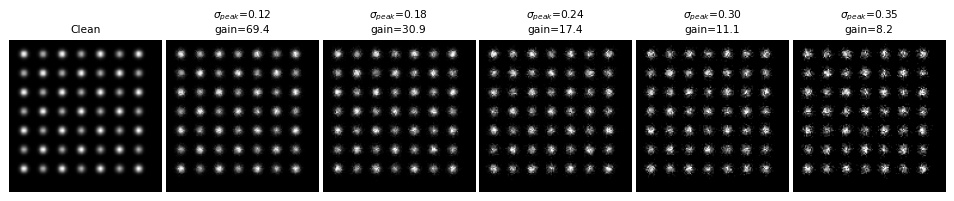

peak_sigma=0.12: gain=69.44, realized global RMSE=0.0318
peak_sigma=0.18: gain=30.86, realized global RMSE=0.0473
peak_sigma=0.24: gain=17.36, realized global RMSE=0.0644
peak_sigma=0.30: gain=11.11, realized global RMSE=0.0787
peak_sigma=0.35: gain=8.16, realized global RMSE=0.0953


In [4]:
panels = [("Clean", clean, None)]
for peak_sigma in peak_sigma_values:
    noisy, metadata = add_poisson_noise_peak_sigma(
        clean,
        peak_sigma=peak_sigma,
        rng=np.random.default_rng(MASTER_SEED),
    )
    title = (
        f"$\\sigma_{{peak}}$={peak_sigma:.2f}\n"
        f"gain={metadata['poisson_gain']:.1f}"
    )
    panels.append((title, noisy, metadata))

figure, axes = plt.subplots(1, len(panels), figsize=(10.5, 2.15))
for axis, (title, image, _) in zip(axes, panels):
    axis.imshow(image.numpy(), cmap="gray", vmin=0.0, vmax=1.0)
    axis.set_title(title, fontsize=8.5)
    axis.axis("off")
figure.tight_layout(pad=0.35)
plt.show()

for peak_sigma, (_, _, metadata) in zip(
    peak_sigma_values, panels[1:]
):
    print(
        f"peak_sigma={peak_sigma:.2f}: "
        f"gain={metadata['poisson_gain']:.2f}, "
        f"realized global RMSE={metadata['realized_global_rmse_raw']:.4f}"
    )